In [1]:
import os

os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=12")
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
for parent in [repo_root, *repo_root.parents]:
    src = parent / "src"
    if (src / "gwemfish").is_dir():
        sys.path.insert(0, str(src))
        break

import matplotlib.pyplot as plt

from gwemfish.simple_pipeline import (
    _deep_merge_dict,
    make_default_cfg,
    plot_system_observation,
    setup_em_observation,
    setup_gw_observation,
    run_inference, 
    plot_posterior, 
    to_source_plane_samples, 
    plot_source_posterior,
)
#
#OUTPUT_DIR = os.path.join("examples", "outputs", "simple_pipeline_demonstration")
#os.makedirs(OUTPUT_DIR, exist_ok=True)
#print("OUTPUT_DIR:", os.path.abspath(OUTPUT_DIR))

In [3]:
from gwemfish.config import DEFAULT_KWARGS_NUMERICS, SOLVER_PARAMS
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.number):
            return obj.item()
        return super().default(obj)

In [38]:
import json
import numpy as np

# 1. Custom encoder to handle the np.float64 types in your existing data
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.number):
            return obj.item()
        return super().default(obj)

# 2. Write your existing 'previous_run' list to the .jsonl file
# Use 'w' mode to create a fresh file (or overwrite if it already exists)
with open('progress_results.jsonl', 'w') as f:
    for run in previous_run:
        json_line = json.dumps(run, cls=NumpyEncoder)
        f.write(json_line + '\n')

print("Successfully saved previous_run to progress_results.jsonl!")

Successfully saved previous_run to progress_results.jsonl!


In [6]:
sample_cfg = {
    "em": {
        "pixel_grid_kwargs": {"npix": int(40), "pix_scl": 0.1},
        "psf_kwargs": {"psf_type": "GAUSSIAN", "fwhm": 0.4, "pixel_size": 0.1},#0.067
        "noise_simu_kwargs": {"npix": int(40), "background_rms": 5e-2, "exposure_time": 2200},
        "noise_inf_kwargs": {"npix": int(40), "background_rms": None, "exposure_time": 2200},
        "kwargs_numerics": DEFAULT_KWARGS_NUMERICS,
        "exposure_time": 2200,
        "seed": 87651,
        "source_pos": (0.0, 0.0), #Is this the position of the source of the GW or the position of the center of the source galaxy?
        "kwargs_source": [
            {
                "amp": 250,
                "R_sersic": 0.4,
                "n_sersic": 4.0,
                "e1": 0,
                "e2": 0,
                "center_x": 0.0, #same question for these center_x and y values
                "center_y": 0.0,
            }
        ],
        "kwargs_lens_light": [
            {
                "amp": 50.0,
                "R_sersic": 2.0,
                "n_sersic": 4.0,
                "e1": 0.0,
                "e2": 0.0,
                "center_x": 0.0,
                "center_y": 0.0,
            }
        ],
    },
    "lens": {
        "lens_model_list": ["EPL", "SHEAR"],
        "kwargs_lens": [
            {
                "theta_E": 1.2,
                "e1": 0.0,
                "e2": 0.1,
                "gamma": 2.0,
                "center_x": 0.0,
                "center_y": 0.0,
            },
            {"gamma1": 0.1, "gamma2": 0.0, "ra_0": 0.0, "dec_0": 0.0},
        ],
        "zl": 0.7,
        "zs": 1.5,
    },
    "gw": {
        "enabled": True,
        "n_images": 2,
        "source_pos": (0.0, 0.0),
        "solver_params": SOLVER_PARAMS,
        "image_box_half_width": 10.6,
        "error_scales": {
            "sigma_td": 0.05,
            "sigma_dL_eff": 0.2,
            "epsilon": 0.005,
        },
    },
    "plot": {"plot_mode": "groupwise", "save_path": None, "save_tag": None, "hist_kwargs": {"density": True}},
    "source_plane": {"filter_std": None, "use_filtered": False},
    "output": {
        "output_dir": OUTPUT_DIR,
        "save_samples_path": None,
        "save_truths_path": None,
        "save_source_samples_path": None,
        "save_system_plot_path": None,
        "json_path": None,
    },
}

def q_pa_to_e1e2(q, pa):
    e = (1-q) / (1+q)
    e1 = float(e * np.cos(2*pa))
    e2 = float(e * np.sin(2*pa))
    return (e1, e2)

def mag_to_amp(mag_value):
    """
    convert between the apparent magnitude in the catalog to Sersic amplitude
    """
    return 60 #for now

    

In [7]:
from lenstronomy.Util import param_util
from lenstronomy.SimulationAPI.mag_amp_conversion import MagAmpConversion

In [8]:
import copy

def row_to_cfg(row, sample_cfg, gw_enabled):
    """
    Convert one row of the Qiuhan's sky catalog into a GWEMFISH configuration.

    Parameters
    ----------
    row : pandas.Series
        One row of the lens catalog.

    sample_cfg : dict
        Reference GWEMFISH config.

    Returns
    -------
    cfg : dict
        GWEMFISH configuration for this lens system.
    """

    cfg = copy.deepcopy(sample_cfg)

    # ==========================================================
    # Convert axis ratio + PA -> ellipticity
    # ==========================================================

    # --- 1. PREPARE LENS (DEFLECTOR) LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])


    kwargs_lens_light_mag = [{
    'magnitude': row['deflector_app_mag_VIS'],
    'R_sersic': row['deflector_Re'],
    'n_sersic': 4.0,  # Standard assumption for elliptical lens galaxies
    'e1': lens_e1, 'e2': lens_e2,
    'center_x': 0, 'center_y': 0
    }]

    # --- 2. PREPARE SOURCE LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    source_e1, source_e2 = param_util.phi_q2_ellipticity(phi=row['source_pa'], q=row['source_q'])
    
    # Choose your band (e.g., VIS)
    kwargs_source_mag = [{
        'magnitude': row['source_app_mag_VIS'], 
        'R_sersic': row['source_Re'],
        'n_sersic': row['source_sersic_index'],
        'e1': source_e1, 'e2': source_e2,
        'center_x': row['source_relative_x'], 
        'center_y': row['source_relative_y']
    }]
    
    # --- 3. CONVERT BOTH TO AMP ---
    # Define your model profile types
    kwargs_model = {
        'lens_light_model_list': ['SERSIC_ELLIPSE'],
        'source_light_model_list': ['SERSIC_ELLIPSE']
    }
    
    # Initialize the converter with your survey zero-point
    mag_converter = MagAmpConversion(kwargs_model=kwargs_model, magnitude_zero_point=25.9)
    
    # Get the final dictionaries containing the calculated 'amp' keys
    lens_light_amp = mag_converter.magnitude2amplitude(kwargs_lens_light_mag=kwargs_lens_light_mag)
    source_amp = mag_converter.magnitude2amplitude(kwargs_source_mag=kwargs_source_mag)
    
    #print(lens_light_amp)
    #print(source_amp)
    
    #source_e1, source_e2 = q_pa_to_e1e2(
     #   row["source_q"],
      #  row["source_pa"],
   # )

    lens_pos = (float(row['deflector_ra']), float(row['deflector_dec']))
    
    source_pos = (float(row["source_relative_x"]), float(row["source_relative_y"]))

    # ==========================================================
    # Lens geometry
    # ==========================================================

    cfg["lens"]["zl"] = float(row["deflector_z"])
    cfg["lens"]["zs"] = float(row["source_z"])

    # ==========================================================
    # Lens mass model (EPL)
    # ==========================================================

    cfg["lens"]["kwargs_lens"][0]["theta_E"] = float(row["deflector_thetaE"])
    cfg["lens"]["kwargs_lens"][0]["gamma"] = float(row["deflector_slope"])

    cfg["lens"]["kwargs_lens"][0]["e1"] = float(lens_e1)
    cfg["lens"]["kwargs_lens"][0]["e2"] = float(lens_e2)

    cfg["lens"]["kwargs_lens"][0]["center_x"] = 0.00
    cfg["lens"]["kwargs_lens"][0]["center_y"] = 0.00

    # ==========================================================
    # External shear
    # ==========================================================

    cfg["lens"]["kwargs_lens"][1]["gamma1"] = float(row["deflector_shear1"])
    cfg["lens"]["kwargs_lens"][1]["gamma2"] = float(row["deflector_shear2"])

    cfg["lens"]["kwargs_lens"][1]["ra_0"] = 0.00
    cfg["lens"]["kwargs_lens"][1]["dec_0"] = 0.00

    # ==========================================================
    # Source light
    # ==========================================================

    cfg["em"]["kwargs_source"][0]["R_sersic"] = float(row["source_Re"])
    cfg["em"]["kwargs_source"][0]["n_sersic"] = float(row["source_sersic_index"])

    cfg["em"]["kwargs_source"][0]["e1"] = float(source_e1)
    cfg["em"]["kwargs_source"][0]["e2"] = float(source_e2)

    cfg["em"]["kwargs_source"][0]["center_x"] = source_pos[0]
    cfg["em"]["kwargs_source"][0]["center_y"] = source_pos[1]

    cfg["em"]["kwargs_source"][0]["amp"] = float(source_amp[1][0]['amp'])

    # ==========================================================
    # Lens light
    # ==========================================================

    cfg["em"]["kwargs_lens_light"][0]["R_sersic"] = float(row["deflector_Re"])
    cfg["em"]["kwargs_lens_light"][0]["n_sersic"] = float(4)

    cfg["em"]["kwargs_lens_light"][0]["e1"] = float(lens_e1)
    cfg["em"]["kwargs_lens_light"][0]["e2"] = float(lens_e2)

    cfg["em"]["kwargs_lens_light"][0]["center_x"] = 0.00
    cfg["em"]["kwargs_lens_light"][0]["center_y"] = 0.00

    cfg["em"]["kwargs_lens_light"][0]["amp"] = float(lens_light_amp[0][0]['amp'])

    # ==========================================================
    # GW source position
    # ==========================================================
    cfg["em"]["source_pos"] = source_pos
    
    if gw_enabled is True:
        cfg["gw"]["source_pos"] = (source_pos[0]+0.005, source_pos[1]-0.005)

    if gw_enabled is False:
        cfg["gw"] = {"enabled": False}

    return cfg

## Prepare to implement data

In [9]:
import pandas as pd

In [10]:
df = pd.read_csv('../catalog/filtered_lens_catalog_PL_IC_gt_70.csv')

In [11]:
df.columns

Index(['deflector_ra', 'deflector_dec', 'deflector_z', 'deflector_q',
       'deflector_pa', 'deflector_vdisp', 'deflector_rband_abs_mag',
       'deflector_Re', 'deflector_thetaE', 'deflector_thetaE_autolens',
       'deflector_slope', 'deflector_einstein_mass', 'deflector_shear1',
       'deflector_shear2', 'source_z', 'source_max_image_multiplicity',
       'source_ra', 'source_dec', 'source_relative_x', 'source_relative_y',
       'source_pa', 'source_q', 'source_Re', 'source_sersic_index',
       'source_mStar', 'source_SFR_100', 'source_metallicity',
       'deflector_app_mag_VIS', 'source_app_mag_VIS', 'source_app_mag_F106',
       'source_app_mag_F129', 'source_app_mag_F158', 'source_app_mag_g',
       'source_app_mag_r', 'source_app_mag_i', 'source_app_mag_z', 'IC_Euclid',
       'IC_CSST', 'IC_Roman', 'IC_nofactor_Euclid', 'IC_nofactor_CSST',
       'IC_nofactor_Roman', 'origin_batch'],
      dtype='str')

In [12]:
df

,deflector_ra,deflector_dec,deflector_z,deflector_q,deflector_pa,deflector_vdisp,deflector_rband_abs_mag,deflector_Re,deflector_thetaE,deflector_thetaE_autolens,...,source_app_mag_r,source_app_mag_i,source_app_mag_z,IC_Euclid,IC_CSST,IC_Roman,IC_nofactor_Euclid,IC_nofactor_CSST,IC_nofactor_Roman,origin_batch
0,18.765015,0.519344,0.612120,0.790645,263.194819,228.748060,-22.853323,0.638501,0.535876,0.538893,...,24.859139,24.612931,24.156885,139.609299,107.140921,374.900774,88.281250,67.750032,237.066650,R1
1,7.384974,13.217773,0.641341,0.833568,88.785537,315.199528,-24.428088,1.021829,0.898221,0.920327,...,24.490169,23.971982,23.307421,175.121376,0.000000,877.628905,106.250000,0.000000,532.476807,R1
2,6.554591,1.669725,1.117882,0.816296,145.348020,265.846351,-23.611113,0.524361,0.478011,0.448648,...,24.024455,24.003017,23.942846,269.853936,631.972622,582.636863,129.296875,302.801161,279.162598,R1
3,10.330458,7.298118,1.019449,0.782827,282.979657,214.256020,-22.550807,0.488209,0.626172,0.639331,...,24.630808,24.469356,24.383268,189.927078,207.916902,531.217594,75.781250,82.959222,211.956787,R1
4,5.521573,12.172388,0.473488,0.946585,295.919087,278.417558,-23.967032,0.715179,1.492396,1.503382,...,25.371767,25.238202,25.109647,1282.653388,2111.513737,3556.239372,139.843750,230.211842,387.725830,R1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458,13.038618,8.576974,0.579102,0.587533,124.584694,160.866823,-21.458484,0.515955,0.390079,0.405767,...,23.342917,23.065671,22.872871,63.412408,120.130388,148.032062,83.203125,157.622522,194.232178,R20
2459,5.478597,13.012276,0.600303,0.899046,348.434543,327.532489,-24.731760,0.497079,1.923783,1.955474,...,23.139402,23.053593,23.004004,407.441418,603.286909,1719.870486,78.906250,116.834238,333.074951,R20
2460,7.799657,14.505096,1.055451,0.786143,344.921621,287.166011,-24.054438,0.492006,0.856864,0.848507,...,24.984803,24.818031,24.627514,425.338859,569.099423,1202.089286,113.671875,152.091908,321.258545,R20
2461,11.374068,4.332397,0.474233,0.563533,286.389224,191.920035,-22.183875,0.796035,0.786668,0.654935,...,25.175398,25.149929,25.141108,558.579736,969.283375,1009.700992,80.078125,138.956697,144.750977,R20


In [13]:
import time
start_time = time.time()

accepted_rows = []
for i in range(200, 1000):

    one_galaxy = df.iloc[i:i+1]

    if one_galaxy.iloc[0]['deflector_thetaE'] < 0.6:
        continue

    row = one_galaxy.iloc[0]
    cfg = row_to_cfg(row, sample_cfg, False)
    cfg["use_parameter_layout"] = True
    ctx = setup_em_observation(cfg=cfg)
    tp_pair = ctx['truth_params']

    if len(tp_pair['x_image_true_em']) < 4:
        continue
    
    #print(f'System {i} is close enough to the GW source and has at least four images. Proceed with manual inspection')
    accepted_rows.append(one_galaxy.iloc[0])

candidates = pd.DataFrame(accepted_rows, columns=df.columns)
print("--- %s seconds ---" % (time.time() - start_time))

--- 521.1875650882721 seconds ---


In [17]:
target_indices = []
for index, _ in candidates.iterrows():
    target_indices.append(index)

In [18]:
target_indices

[206,
 212,
 222,
 229,
 230,
 239,
 263,
 271,
 281,
 303,
 320,
 329,
 340,
 343,
 406,
 419,
 425,
 426,
 430,
 441,
 447,
 463,
 491,
 510,
 536,
 552,
 553,
 565,
 570,
 575,
 577,
 585,
 604,
 609,
 623,
 627,
 634,
 639,
 641,
 658,
 673,
 686,
 695,
 701,
 702,
 739,
 787,
 790,
 804,
 805,
 807,
 811,
 817,
 818,
 832,
 857,
 896,
 904,
 917,
 920,
 957,
 959,
 962,
 970,
 977,
 982,
 984,
 985]

target_indices = [206, 212,222,229,230,239,263,271,281,303,320,329,340,343,406,419,425,426,430,441,447,463,491,510,536,552,553,565,570,575,577,585,604,609,623,627,634,639,641,658,673,
 686,695,701,702,739,787,790,804,805,807,811,817,818,832,857,896,904,917,920,957,959,962,970,977,982,984,985]

candidates = df.loc[target_indices]

In [19]:
candidates

,deflector_ra,deflector_dec,deflector_z,deflector_q,deflector_pa,deflector_vdisp,deflector_rband_abs_mag,deflector_Re,deflector_thetaE,deflector_thetaE_autolens,...,source_app_mag_r,source_app_mag_i,source_app_mag_z,IC_Euclid,IC_CSST,IC_Roman,IC_nofactor_Euclid,IC_nofactor_CSST,IC_nofactor_Roman,origin_batch
206,0.928908,0.692962,0.448578,0.706715,24.029338,184.958073,-21.966783,0.412514,0.748631,0.751576,...,24.475275,24.519392,24.465139,274.182656,443.823998,672.203781,96.093750,155.548542,235.589600,R2
212,12.542042,14.176619,0.224995,0.419489,294.288384,287.505203,-23.956680,1.007817,1.096597,1.022605,...,22.320359,21.501241,21.166925,1826.008364,3831.353817,4484.427112,113.671875,238.507764,279.162598,R2
222,7.059164,13.176880,0.236537,0.730203,1.672962,190.465541,-22.074413,0.664110,0.876488,0.814746,...,25.238190,25.230850,25.160480,382.788445,447.960657,1305.977229,119.921875,140.339351,409.143066,R2
229,1.266766,0.085857,0.582593,0.607902,223.076124,214.579387,-22.577235,0.502036,0.852431,0.876277,...,24.947479,24.991125,25.099723,397.155610,708.485380,807.711266,98.046875,174.905694,199.401855,R2
230,7.420703,11.605797,0.346540,0.339653,240.996673,171.382774,-21.751064,0.655471,0.622530,0.584443,...,24.544661,24.845265,24.967343,194.783934,323.729314,618.757245,76.953125,127.895468,244.451904,R2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,8.809442,2.826033,0.849271,0.852909,4.036390,229.941069,-22.848969,0.623152,0.799277,0.808993,...,24.993974,24.749218,24.684939,486.130386,900.839125,1099.304037,99.609375,184.584270,225.250244,R8
977,8.548170,5.070673,0.515990,0.670370,287.193817,255.424563,-23.510933,0.528918,1.215138,1.273760,...,25.230894,25.108038,24.964369,603.445906,670.004187,2405.555626,82.812500,91.946471,330.120850,R8
982,14.302967,4.796082,0.620435,0.573258,284.890781,278.008273,-23.767862,0.756682,1.314339,1.346045,...,24.685157,24.790480,24.876723,702.216754,1263.356768,1696.902718,117.968750,212.237344,285.070801,R9
984,5.122924,4.483851,0.955978,0.728142,342.426292,286.166477,-24.007137,0.680705,1.171595,1.189421,...,25.529957,25.738894,25.744223,497.864714,24.671342,1592.638102,97.656250,4.839288,312.396240,R9


In [20]:
from scipy.stats import gaussian_kde
shared_params = ['lens0_e1', 'lens0_e2', 'lens0_gamma', 'lens0_theta_E', 'lens1_gamma1', 'lens1_gamma2']

In [21]:
import numpyro.distributions as dist
from gwemfish import prune_gw_images

In [22]:
from scipy.stats import norm
from scipy.special import logsumexp

sample_truth_pairs = []

In [23]:
start = 0
finish = 2
this_run = candidates.iloc[start:finish]

----------------------------------------Starting 206-th iteration---------------------------------------------------
use_mst in probmodel: False
k_mst in keys_to_include: False
k_mst truth: None
keys_to_include: ['lens0_gamma', 'lens0_theta_E', 'lens0_e1', 'lens0_e2', 'lens1_gamma1', 'lens1_gamma2', 'source0_amp', 'source0_R_sersic', 'source0_n_sersic', 'source0_e1', 'source0_e2', 'source0_center_x', 'source0_center_y']
input_params: {'lens0_gamma': 1.9157183212956164, 'lens0_theta_E': 0.7486310892580076, 'lens0_e1': -0.1020723929338042, 'lens0_e2': -0.13824214428666043, 'lens1_gamma1': 0.0061570576880828, 'lens1_gamma2': 0.0245301960362667, 'source0_amp': 3.164928091461574, 'source0_R_sersic': 0.2634074092781437, 'source0_n_sersic': 2.0321841811682853, 'source0_e1': -0.724639869416779, 'source0_e2': 0.2144333343972051, 'source0_center_x': 0.0370987784972243, 'source0_center_y': -0.0547204998729178}
Done with gradient
Done with Hessian
Running informed HMC
Hessian-informed MCMC:
  u0: 

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

...

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]



[image_x1]      	 max r_hat: 1.0000


[image_x2]      	 max r_hat: 1.0000


[image_x3]      	 max r_hat: 1.0000


[image_x4]      	 max r_hat: 1.0000


[image_y1]      	 max r_hat: 1.0000


[image_y2]      	 max r_hat: 1.0000


[image_y3]      	 max r_hat: 1.0000


[image_y4]      	 max r_hat: 1.0000


[lens0_e1]      	 max r_hat: 1.0000


[lens0_e2]      	 max r_hat: 1.0000


[lens0_gamma]   	 max r_hat: 1.0000


[lens0_theta_E]  	 max r_hat: 1.0000


[lens1_gamma1]  	 max r_hat: 1.0000


[lens1_gamma2]  	 max r_hat: 1.0000
-------------------Finished parameter estimation -------------------------
-------------------Finished computing logZ_em-------------------------
-------------------Finished evaluating the integral -------------------------
----------------------------------------Finished 212-th iteration---------------------------------------------------


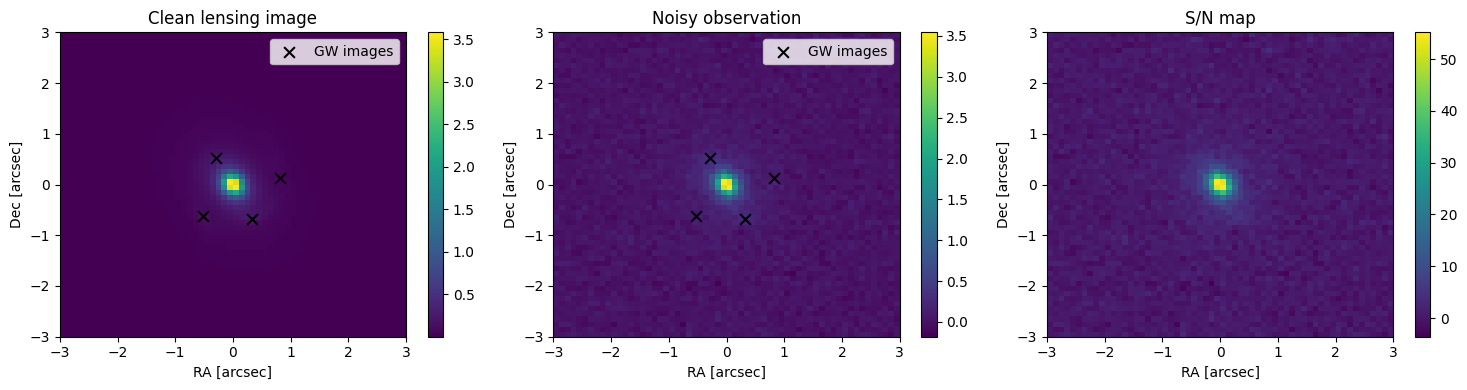

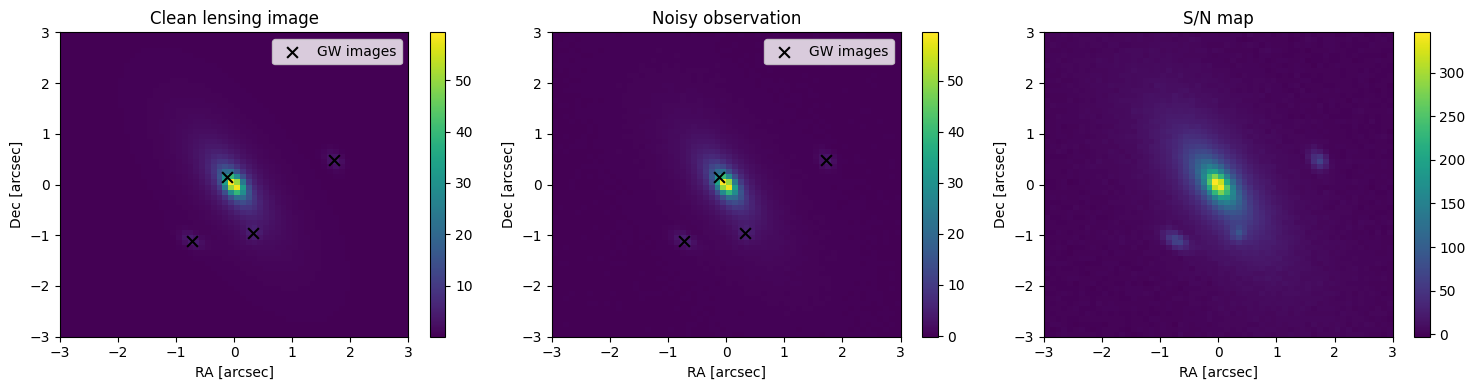

In [24]:
for idx, row in this_run.iterrows():

    print(f'----------------------------------------Starting {idx}-th iteration---------------------------------------------------')
    
    #row = candidates.iloc[i]
    cfg_org = row_to_cfg(row, sample_cfg, True)
    cfg_org['em']['pixel_grid_kwargs']['npix'] = 60
    cfg_org['em']['noise_simu_kwargs']['npix'] = 60
    cfg_org['em']['noise_inf_kwargs']['npix'] = 60
    cfg_org['em']['psf_kwargs']['fwhm'] = 0.18
    
    cfg_org["use_parameter_layout"] = True

    ctx_post_em = setup_em_observation(cfg=cfg_org)
    ctx = setup_gw_observation(ctx_post_em, cfg=cfg_org)
    
    
    if len(ctx["x_img_gw"]) < 4:
        print('-----------END: LESS THAN 4 IMAGES----------')
        continue
        
    if len(ctx["x_img_gw"]) > 4:
        ctx = prune_gw_images(ctx, n_keep=4)
    
    #save true values
    tp = ctx['truth_params']
    fig = plot_system_observation(
        ctx,
        cfg={"output": {"save_system_plot_path": os.path.join(OUTPUT_DIR, f"system_observation_{idx}.png")}},
    )

    ctx["cfg"]["priors"] = {
        "T_star": float(tp["T_star"]),
        "dL": float(tp["dL"]),
        'lens0_gamma': dist.TruncatedNormal(tp['lens0_gamma'], 0.1, low=0.001, high=5.0),
        'lens0_theta_E': dist.TruncatedNormal(tp['lens0_theta_E'], 0.1, low=0.001, high=5.0),
         #'lens0_e1': float(tp["lens0_e1"]), 
         #'lens0_e2': float(tp['lens0_e2']),
         'lens0_e1': dist.Normal(tp['lens0_e1'], 0.01),
         'lens0_e2': dist.Normal(tp['lens0_e2'], 0.01),
         'lens0_center_x': 0.0,
         'lens0_center_y': 0.0,
         #'lens1_gamma1': float(tp["lens1_gamma1"]),
         #'lens1_gamma2': float(tp["lens1_gamma2"]),
         'lens1_gamma1': dist.Normal(tp['lens1_gamma1'], 0.01),
         'lens1_gamma2': dist.Normal(tp['lens1_gamma2'], 0.01),
         'lens1_ra_0': 0.0,
         'lens1_dec_0': 0.0,
          'light0_R_sersic': float(tp["light0_R_sersic"]),
          'light0_n_sersic': float(tp["light0_n_sersic"]),
          'light0_amp': float(tp['light0_amp']),
         'light0_e1': float(tp["light0_e1"]),
         'light0_e2': float(tp["light0_e2"]),
         'light0_center_x': float(tp["light0_center_x"]),
         'light0_center_y': float(tp["light0_center_y"]),
          "noise_sigma_bkg": tp["noise_sigma_bkg"],  
        } 

    ctx_em = copy.deepcopy(ctx)
    ctx_gw = copy.deepcopy(ctx)
    
    
    #perform the parameter estimation in EM-only mode
    method = 'deriv-approx'
    
    samples_em, truths_em = run_inference(
    ctx_em,
    mode="EM-only",#"EM-only",#"GW-only",
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
    },
    )

    #Param est for GW-only mode
    
    samples_gw, truths_gw = run_inference(
    ctx_gw,
    mode="GW-only",#"EM-only",#"GW-only",
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
    },
    )

    #param sigmas and check if NaN values exists
    has_any_nan_em = any(np.isnan(arr).any() for arr in samples_em.values())
                
    has_any_nan_gw = any(np.isnan(arr).any() for arr in samples_gw.values())
    
    if has_any_nan_gw or has_any_nan_em:
        print("--------------------UH OH! Parameter estimation exploded!!!! Contains NaN values-----------------")
        break

    print(f'-------------------Finished parameter estimation -------------------------')
    
    #compute the em only evidence
    logp0_em = float(ctx_em["fisher"]["logp0"]) #true point, 
    H_em = np.asarray(ctx_em["fisher"]["H0"]) # also around true point
    
    k_em = H_em.shape[0]
    
    sign_em, logdet_em = np.linalg.slogdet(-H_em) #Compute the sign and (natural) logarithm of the determinant of an array.
    
    logZ_em = (
        logp0_em
        + 0.5 * k_em * np.log(2*np.pi)
        - 0.5 * logdet_em
    )


    samples_matrix_GW = np.vstack([samples_gw[p] for p in shared_params])
    #defining the gaussian kde
    kde_gw = gaussian_kde(samples_matrix_GW)
    
    print(f'-------------------Finished computing logZ_em-------------------------')
    
    #compute the joint evidence with monte carlo integration
    samples_matrix_EM = np.vstack([samples_em[p] for p in shared_params])
    
    p_gw = kde_gw(samples_matrix_EM)
    
    gamma_samples = np.asarray(samples_em["lens0_gamma"])
    thetaE_samples = np.asarray(samples_em["lens0_theta_E"])
    e1_samples = np.asarray(samples_em["lens0_e1"])
    e2_samples = np.asarray(samples_em["lens0_e2"])
    gamma1_samples = np.asarray(samples_em["lens1_gamma1"])
    gamma2_samples = np.asarray(samples_em["lens1_gamma2"])
    
    log_prior = (
        norm.logpdf(gamma_samples,tp['lens0_gamma'],0.1)
        + norm.logpdf(thetaE_samples,tp['lens0_theta_E'],0.1)
        + norm.logpdf(e1_samples,tp['lens0_e1'],0.01)
        + norm.logpdf(e2_samples,tp['lens0_e2'],0.01)
        + norm.logpdf(gamma1_samples,tp['lens1_gamma1'],0.01)
        + norm.logpdf(gamma2_samples,tp['lens1_gamma2'],0.01)
    )
    
    log_integrand = np.log(p_gw) - log_prior
    
    log_I = logsumexp(log_integrand) - np.log(len(log_integrand))
    
    I = np.exp(log_I)

    print(f'-------------------Finished evaluating the integral -------------------------')

    result_dict =  {'index': idx,
                    'truths_em': truths_em, 
                    'logZ_em': logZ_em,
                    'I': I,
                    'logZ_em+log_I': (logZ_em + log_I)}
    
    #sample_truth_pairs.append(result)
    
    # 2. Append directly to the file immediately
    with open('progress_results.jsonl', 'a') as f:
        json_line = json.dumps(result_dict, cls=NumpyEncoder)
        f.write(json_line + '\n')

    print(f'----------------------------------------Finished {idx}-th iteration---------------------------------------------------')

In [34]:
# 1. Read all lines from the file
with open('progress_results.jsonl', 'r') as f:
    lines = f.readlines()

# 2. Slice the list to remove the last two lines
# (This leaves out the accidental duplicates)
cleaned_lines = lines[8:10]

# 3. Overwrite the file with the cleaned data
with open('progress_results.jsonl', 'w') as f:
    f.writelines(cleaned_lines)

print(f"Done! Removed 2 lines. File now has {len(cleaned_lines)} lines.")

Done! Removed 2 lines. File now has 2 lines.


In [35]:
import json

# Initialize an empty list to store the recovered data
loaded_run = []

# Open and read the file line by line
with open('progress_results.jsonl', 'r') as f:
    for line in f:
        if line.strip():  # This skips any accidental empty lines
            loaded_run.append(json.loads(line))

print(f"Successfully loaded {len(loaded_run)} items from the file!")

Successfully loaded 2 items from the file!


In [36]:
EM_contributions = []
for i in range(len(loaded_run)):
    print(loaded_run[i]['I'])
    EM_contributions.append(loaded_run[i]['I'])

6.277203365043113e-151
0.0


(array([3., 1., 2., 3., 1., 0., 0., 0., 0., 1.]),
 array([ 0.        ,  2.81077876,  5.62155752,  8.43233629, 11.24311505,
        14.05389381, 16.86467257, 19.67545133, 22.48623009, 25.29700886,
        28.10778762]),
 <BarContainer object of 10 artists>)

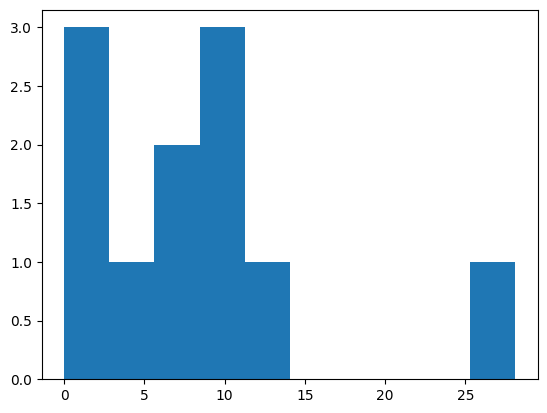

In [33]:
plt.hist(EM_contributions)